In [9]:
import re, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load data

In [55]:
data = dict()

In [56]:
def get_nascseq_snr(cells):
    array = []
    for cell in cells:
        path = "../../2_NASCseq/results/5_stat/3_snr/%s/%s.snr.csv" % (cell.split(".")[0], cell)
        array.append(pd.read_csv(path, index_col=0))
    m = pd.concat(array)
    return m

# NASC-seq

info = pd.read_csv("../../2_NASCseq/reports/NASCseq_Summary.csv", index_col=0)
info = info[[not run.startswith("GSE") for run in info["Run"]]]
print(info.shape)
info = info[info["Stranded.Reads"] >= 200000]
print(info.shape)

for s4u, d1 in info.groupby(by="s4U"):
    for time, d2 in d1.groupby(by="Time"):
        data["NASCseq.K562.s4U_%duM_%dmin" % (s4u, time * 60)] = get_nascseq_snr(d2.index)

# NASC-seq (GSE128273)

info = pd.read_csv("../../2_NASCseq/reports/NASCseq_Summary.csv", index_col=0)
info = info[[run.startswith("GSE") for run in info["Run"]]]
print(info.shape)
info = info[info["Stranded.Reads"] >= 200000]
print(info.shape)

for s4u, d1 in info.groupby(by="s4U"):
    for time, d2 in d1.groupby(by="Time"):
        data["GSE128273_NASCseq.K562.s4U_%duM_%dmin" % (s4u, time * 60)] = get_nascseq_snr(d2.index)

(143, 43)
(142, 43)
(284, 43)
(260, 43)


In [57]:
def get_nanonascseq_snr(cells, level):
    array = []
    for cell in cells:
        if level == "raw":
            path = "../../1_NanoNASCseq/results/9_stat/2_snr_raw/%s/%s.snr.csv" % (cell.split(".")[0], cell)
        elif level == "corrected":
            path = "../../1_NanoNASCseq/results/9_stat/2_snr_corrected/%s/%s.snr.csv" % (cell.split(".")[0], cell)
        elif level == "linkage":
            path = "../../1_NanoNASCseq/results/9_stat/2_snr_linkage/%s/%s.snr.csv" % (cell.split(".")[0], cell)
        else:
            assert False
        array.append(pd.read_csv(path, index_col=0))
    m = pd.concat(array)
    return m
    
runs = ["20220719_K562_1", "20220719_K562_2", 
        "20220719_K562_3", "20220719_K562_4", 
        "20220729_K562_1", "20220729_K562_2"]
info = pd.read_csv("../../1_NanoNASCseq/reports/NanoNASCseq_Summary.csv", index_col=0)
info = info[[x in runs for x in info["Run"]]]
info = info[(info["CellLine"] == "K562") & (info["ActD"].isna()) & (info["UMIs"] >= 5000)]
print(info.shape)
for s4u, d1 in info.groupby(by="s4U"):
    for time, d2 in d1.groupby(by="Time"):
        if s4u == 50 and time == 3:
            d2 = d2[d2["TC.Ratio"] >= 0.008]
        data["NanoNASCseq.K562.s4U_%duM_%dmin.raw" % (s4u, time * 60)] = get_nanonascseq_snr(d2.index, "raw")
        data["NanoNASCseq.K562.s4U_%duM_%dmin.corrected" % (s4u, time * 60)] = get_nanonascseq_snr(d2.index, "corrected")
        data["NanoNASCseq.K562.s4U_%duM_%dmin.linkage" % (s4u, time * 60)] = get_nanonascseq_snr(d2.index, "linkage")

runs = ["20220818_mESC_1", "20220818_mESC_2", "20220818_mESC_3"]
info = pd.read_csv("../../1_NanoNASCseq/reports/NanoNASCseq_Summary.csv", index_col=0)
info = info[[x in runs for x in info["Run"]]]
info = info[(info["CellLine"] == "mESC") & (info["ActD"].isna()) & (info["UMIs"] >= 5000)]
print(info.shape)
for s4u, d1 in info.groupby(by="s4U"):
    for time, d2 in d1.groupby(by="Time"):
        if s4u == 400 and time == 3:
            d2 = d2[d2["TC.Ratio"] >= 0.01]
        data["NanoNASCseq.mESC.s4U_%duM_%dmin.raw" % (s4u, time * 60)] = get_nanonascseq_snr(d2.index, "raw")
        data["NanoNASCseq.mESC.s4U_%duM_%dmin.corrected" % (s4u, time * 60)] = get_nanonascseq_snr(d2.index, "corrected")
        data["NanoNASCseq.mESC.s4U_%duM_%dmin.linkage" % (s4u, time * 60)] = get_nanonascseq_snr(d2.index, "linkage")

(426, 48)
(213, 48)


In [79]:
pickle.dump(data, open("results/signal_to_noise_ratio.data.pkl", "wb"))

# Report summary

In [11]:
data = pickle.load(open("results/signal_to_noise_ratio.data.pkl", "rb"))

rows = []
for name, d in sorted(data.items()):
    d2 = d[~d["Pc"].isna()]
    rows.append([
        name,
        len(d),
        len(d2),
        np.median(d2["Pe"]),
        np.mean(d2["Pe"]),
        np.std(d2["Pe"]),
        np.median(d2["Pc"]),
        np.mean(d2["Pc"]),
        np.std(d2["Pc"]),
        np.median(d2["SNR"]),
        np.mean(d2["SNR"]),
        np.std(d2["SNR"]),
    ])
columns=[
    "Name", "Cells", "Cells[Succeed]", 
    "Median of Pe", "Mean of Pe", "Std of Pe",
    "Median of Pc", "Mean of Pc", "Std of Pc",
    "Median of SNR", "Mean of SNR", "Std of SNR",
]
m = pd.DataFrame(rows, columns=columns)
m.to_csv("results/signal_to_noise_ratio.summary.csv", index=False)

# Plot signal-to-noise ratio

--------------------------------------------------------------------------------
Name: GSE128273_NASCseq.K562.s4U_50uM_180min
Median SNR (control): 1.0682991777450934
Median SNR (treatment): 27.079645012968317


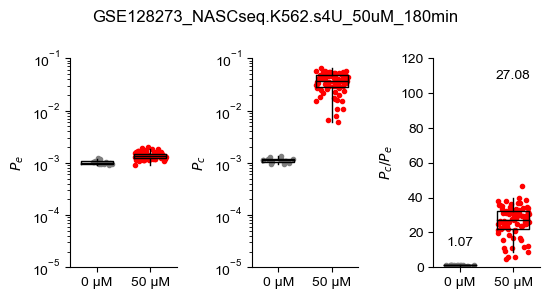

--------------------------------------------------------------------------------
Name: NASCseq.K562.s4U_50uM_180min
Median SNR (control): 1.1453758552740827
Median SNR (treatment): 62.71104310126685


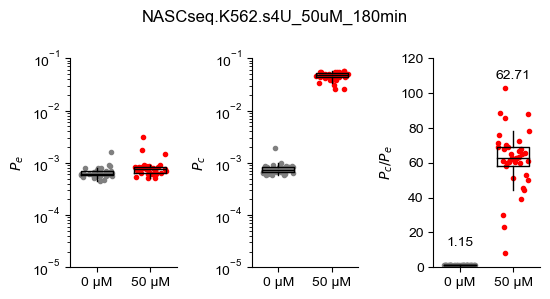

--------------------------------------------------------------------------------
Name: NanoNASCseq.K562.s4U_50uM_180min.raw
Median SNR (control): 3.1660935775672767
Median SNR (treatment): 20.99577043743229


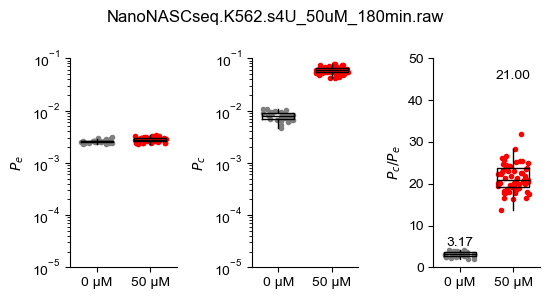

--------------------------------------------------------------------------------
Name: NanoNASCseq.K562.s4U_50uM_180min.corrected
Median SNR (control): 1.028112648577058
Median SNR (treatment): 181.3991943970591


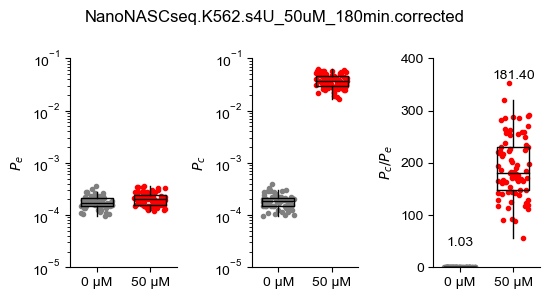

--------------------------------------------------------------------------------
Name: NanoNASCseq.K562.s4U_50uM_180min.linkage
Median SNR (control): 1.1104815260476015
Median SNR (treatment): 925.5725250909364


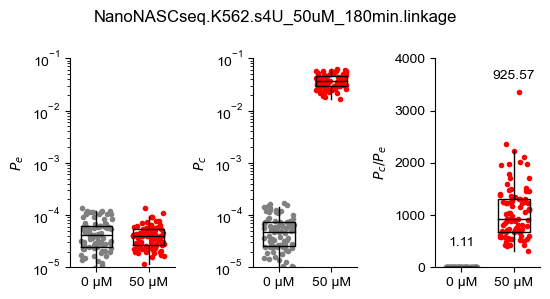

--------------------------------------------------------------------------------
Name: NanoNASCseq.mESC.s4U_400uM_180min.raw
Median SNR (control): 3.332053251326475
Median SNR (treatment): 13.138228051929197


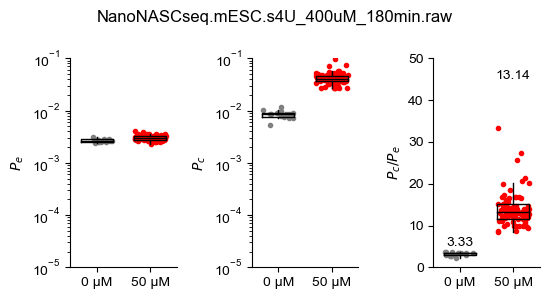

--------------------------------------------------------------------------------
Name: NanoNASCseq.mESC.s4U_400uM_180min.corrected
Median SNR (control): 1.0103882078198367
Median SNR (treatment): 157.3034114303182


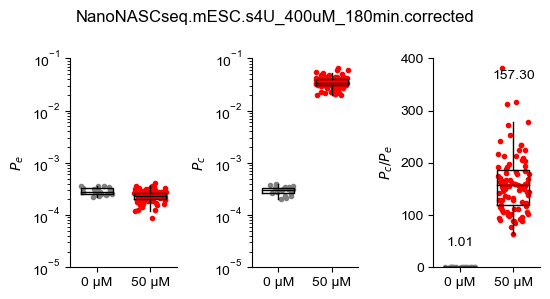

--------------------------------------------------------------------------------
Name: NanoNASCseq.mESC.s4U_400uM_180min.linkage
Median SNR (control): 1.108576081830688
Median SNR (treatment): 672.8257074646779


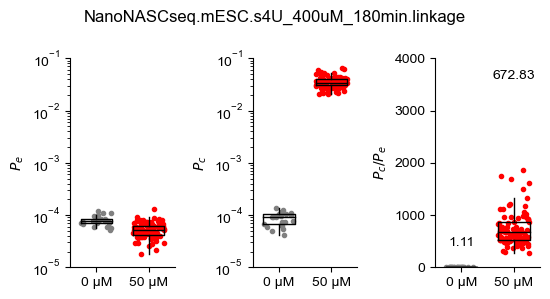

In [99]:
data = pickle.load(open("results/signal_to_noise_ratio.data.pkl", "rb"))

params = [
    ["GSE128273_NASCseq.K562.s4U_50uM_180min", "GSE128273_NASCseq.K562.s4U_0uM_180min", "GSE128273_NASCseq.K562.s4U_50uM_180min"],
    ["NASCseq.K562.s4U_50uM_180min", "NASCseq.K562.s4U_0uM_180min", "NASCseq.K562.s4U_50uM_180min"],
    ["NanoNASCseq.K562.s4U_50uM_180min.raw", "NanoNASCseq.K562.s4U_0uM_180min.raw", "NanoNASCseq.K562.s4U_50uM_180min.raw"],
    ["NanoNASCseq.K562.s4U_50uM_180min.corrected", "NanoNASCseq.K562.s4U_0uM_180min.corrected", "NanoNASCseq.K562.s4U_50uM_180min.corrected"],
    ["NanoNASCseq.K562.s4U_50uM_180min.linkage", "NanoNASCseq.K562.s4U_0uM_180min.linkage", "NanoNASCseq.K562.s4U_50uM_180min.linkage"],
    ["NanoNASCseq.mESC.s4U_400uM_180min.raw", "NanoNASCseq.mESC.s4U_0uM_180min.raw", "NanoNASCseq.mESC.s4U_400uM_180min.raw"],
    ["NanoNASCseq.mESC.s4U_400uM_180min.corrected", "NanoNASCseq.mESC.s4U_0uM_180min.corrected", "NanoNASCseq.mESC.s4U_400uM_180min.corrected"],
    ["NanoNASCseq.mESC.s4U_400uM_180min.linkage", "NanoNASCseq.mESC.s4U_0uM_180min.linkage", "NanoNASCseq.mESC.s4U_400uM_180min.linkage"],
]

for name, k1, k2 in params:
    print("-" * 80)
    print("Name:", name)
    d1, d2 = data[k1], data[k2]

    ticks = ["0 μM", "%s μM" % re.search("[0-9]+uM", "NanoNASCseq.K562.s4U_50uM_180min.raw")[0][:-2]]
    d1 = d1[~(d1["Pe"].isna() | d1["Pc"].isna())]
    d2 = d2[~(d2["Pe"].isna() | d2["Pc"].isna())]
        
    np.random.seed(0)
    colors = ["grey", "red"]
    w = 0.6
    
    pc1, pe1 = d1["Pc"], d1["Pe"]
    pc2, pe2 = d2["Pc"], d2["Pe"]
         
    fig, axs = plt.subplots(1, 3, figsize=(5.6, 3))
    fig.suptitle(name)
    
    plt.sca(axs[0])
    ys_list = [pe1, pe2]
    plt.boxplot(ys_list, positions=[0, 1], widths=w, 
                showcaps=False, showfliers=False, medianprops={"color": "black"})
    for x, ys in enumerate(ys_list):
        xs = np.random.rand(len(ys)) * w + x - w/2
        plt.scatter(xs, ys, marker=".", color=colors[x])
    plt.gca().set_yscale("log")
    plt.xticks([0, 1], ticks)
    plt.ylim(0.00001, 0.1)
    plt.ylabel(r'$P_e$')
    
    plt.sca(axs[1])
    ys_list = [pc1, pc2]
    plt.boxplot(ys_list, positions=[0, 1], widths=w, 
                showcaps=False, showfliers=False, medianprops={"color": "black"})
    for x, ys in enumerate(ys_list):
        xs = np.random.rand(len(ys)) * w + x - w/2
        plt.scatter(xs, ys, marker=".", color=colors[x])
    plt.gca().set_yscale("log")
    plt.xticks([0, 1], ticks)
    plt.ylim(0.00001, 0.1)
    plt.ylabel(r'$P_c$')
    
    plt.sca(axs[2])
    ys_list = [pc1 / pe1, pc2 / pe2]
    print("Median SNR (control):", np.median(ys_list[0]))
    print("Median SNR (treatment):", np.median(ys_list[1]))
    plt.boxplot(ys_list, positions=[0, 1], widths=w, 
                showcaps=False, showfliers=False, medianprops={"color": "black"})
    for x, ys in enumerate(ys_list):
        xs = np.random.rand(len(ys)) * w + x - w/2
        plt.scatter(xs, ys, marker=".", color=colors[x])
    plt.xticks([0, 1], ticks)
    if "NanoNASCseq" in name:
        if "raw" in name:
            ylim = 50
        elif "corrected" in name:
            ylim = 400
        elif "linkage" in name:
            ylim = 4000
        else:
            assert False
    else:
        ylim = 120
    plt.ylim(0, ylim)
    plt.ylabel(r'$P_c/P_e$')

    plt.text(0, ylim * 0.1, "%.2f" % np.median(ys_list[0]), ha="center")
    plt.text(1, ylim * 0.9, "%.2f" % np.median(ys_list[1]), ha="center")
    
    for ax in axs:
        for loc in ["top", "right"]:
            ax.spines[loc].set_visible(False)
    
    plt.tight_layout()
    plt.savefig("figures/signal_to_noise.boxplot.%s.pdf" % name)
    plt.show()
    plt.close()

# Comprehensive comparison

In [91]:
data = pickle.load(open("results/signal_to_noise_ratio.data.pkl", "rb"))

def get_snr(name):
    ys = data[name]["SNR"]
    return ys[~ys.isna()]

names = [
    "GSE128273_NASCseq.K562.s4U_0uM_180min", 
    "GSE128273_NASCseq.K562.s4U_50uM_60min", 
    "GSE128273_NASCseq.K562.s4U_50uM_180min", 
    "NASCseq.K562.s4U_0uM_180min", 
    "NASCseq.K562.s4U_50uM_180min", 
    "NanoNASCseq.K562.s4U_0uM_180min.corrected", 
    "NanoNASCseq.K562.s4U_50uM_180min.corrected"]
colors = ["grey", "red", "red", "grey", "red", "grey", "red"]
array = [get_snr(name) for name in names]

for i, ys in enumerate(array):
    print("-" * 80)
    print(names[i])
    print("Mean:", np.mean(ys))
    print("Median:", np.median(ys))

--------------------------------------------------------------------------------
GSE128273_NASCseq.K562.s4U_0uM_180min
Mean: 1.0855439793757622
Median: 1.0682991777450654
--------------------------------------------------------------------------------
GSE128273_NASCseq.K562.s4U_50uM_60min
Mean: 14.775346655914715
Median: 11.474035462982085
--------------------------------------------------------------------------------
GSE128273_NASCseq.K562.s4U_50uM_180min
Mean: 26.372293145814858
Median: 27.07964501296661
--------------------------------------------------------------------------------
NASCseq.K562.s4U_0uM_180min
Mean: 1.1762009663661703
Median: 1.1453758552740527
--------------------------------------------------------------------------------
NASCseq.K562.s4U_50uM_180min
Mean: 61.84178616886476
Median: 62.71104310126315
--------------------------------------------------------------------------------
NanoNASCseq.K562.s4U_0uM_180min.corrected
Mean: 1.0412643036267915
Median: 1.02811264

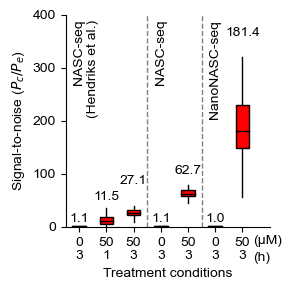

In [94]:
w = 0.5
text_ys = [10, 50, 80, 10, 100, 10, 360]

plt.figure(figsize=(3, 3))
for i, ys in enumerate(array):
    plt.boxplot([array[i]], positions=[i], widths=w, patch_artist=True, 
        showcaps=False, 
        boxprops={"facecolor": colors[i]},
        medianprops={"color": "black"},
        showfliers=False, 
        flierprops={"markerfacecolor": colors[i], "markeredgecolor": "none", "marker": "."})
    plt.text(i, text_ys[i], round(np.median(ys), 1), ha="center")
plt.xticks([0, 1, 2, 3, 4, 5, 6], ["0\n3", "50\n1", "50\n3", "0\n3", "50\n3", "0\n3", "50\n3"])
plt.axvline(2.5, lw=1, ls="--", color="grey")
plt.axvline(4.5, lw=1, ls="--", color="grey")

plt.text(0, 390, "NASC-seq", rotation=90, va="top", ha="center")
plt.text(0.5, 390, "(Hendriks et al.)", rotation=90, va="top", ha="center")
plt.text(3, 390, "NASC-seq", rotation=90, va="top", ha="center")
plt.text(5, 390, "NanoNASC-seq", rotation=90, va="top", ha="center")

plt.text(6.4, -33, "(μM)")
plt.text(6.4, -65, "(h)")
plt.xlim(-0.5, 7)
plt.ylim(0, 400)
plt.xlabel("Treatment conditions")
plt.ylabel(r"Signal-to-noise ($P_c/P_e$)")
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig("figures/comparison_of_snr.boxplot.pdf")
plt.show()
plt.close()

--------------------------------------------------------------------------------
Mean: 1.0412643036267915
Median: 1.0281126485771197
--------------------------------------------------------------------------------
Mean: 191.69504620880932
Median: 181.39919439704568
--------------------------------------------------------------------------------
Mean: 1.142144007777638
Median: 1.1104815260476015
--------------------------------------------------------------------------------
Mean: 1066.56192460795
Median: 925.5725250909364


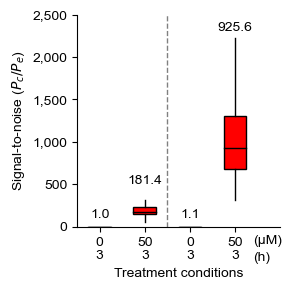

In [98]:
array = []
ys = data["NanoNASCseq.K562.s4U_0uM_180min.corrected"]["SNR"]
array.append(ys[~ys.isna()])
ys = data["NanoNASCseq.K562.s4U_50uM_180min.corrected"]["SNR"]
array.append(ys[~ys.isna()])
ys = data["NanoNASCseq.K562.s4U_0uM_180min.linkage"]["SNR"]
array.append(ys[~ys.isna()])
ys = data["NanoNASCseq.K562.s4U_50uM_180min.linkage"]["SNR"]
array.append(ys[~ys.isna()])

colors = ["grey", "red", "grey", "red"]

plt.figure(figsize=(3, 3))
w = 0.5
text_ys = [100, 500, 100, 2300]
for i, ys in enumerate(array):
    print("-" * 80)
    print("Mean:", np.mean(ys))
    print("Median:", np.median(ys))
    plt.boxplot([array[i]], positions=[i], widths=w, patch_artist=True, 
        showcaps=False, 
        boxprops={"facecolor": colors[i]},
        medianprops={"color": "black"},
        showfliers=False, 
        flierprops={"markerfacecolor": colors[i], "markeredgecolor": "none", "marker": "."})
    plt.text(i, text_ys[i], round(np.median(ys), 1), ha="center")
plt.xticks([0, 1, 2, 3], ["0\n3", "50\n3", "0\n3", "50\n3"])
plt.axvline(1.5, lw=1, ls="--", color="grey")

xlim = 4
ylim = 2500
plt.text(3.4, -0.0825*ylim, "(μM)")
plt.text(3.4, -0.1625*ylim, "(h)")
plt.xlim(-0.5, xlim)
plt.ylim(0, ylim)
ys1 = np.arange(0, 2500 + 1, 500)
plt.yticks(ys1, [format(y, ",") for y in ys1])
plt.xlabel("Treatment conditions")
plt.ylabel(r"Signal-to-noise ($P_c/P_e$)")
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("figures/comparison_with_linkage_snr.boxplot.pdf")
plt.show()
plt.close()